In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

df_raw = pd.read_csv("../data/superstore.csv.csv", encoding="latin1")
df_raw.columns = df_raw.columns.str.strip()

print(df_raw.shape)
print(df_raw.columns.tolist())

(9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [3]:
df_raw["Order Date"] = pd.to_datetime(df_raw["Order Date"])
df_raw["Year"] = df_raw["Order Date"].dt.year
df_raw["Month"] = df_raw["Order Date"].dt.month

print(df_raw["Order Date"].min())
print(df_raw["Order Date"].max())

2014-01-03 00:00:00
2017-12-30 00:00:00


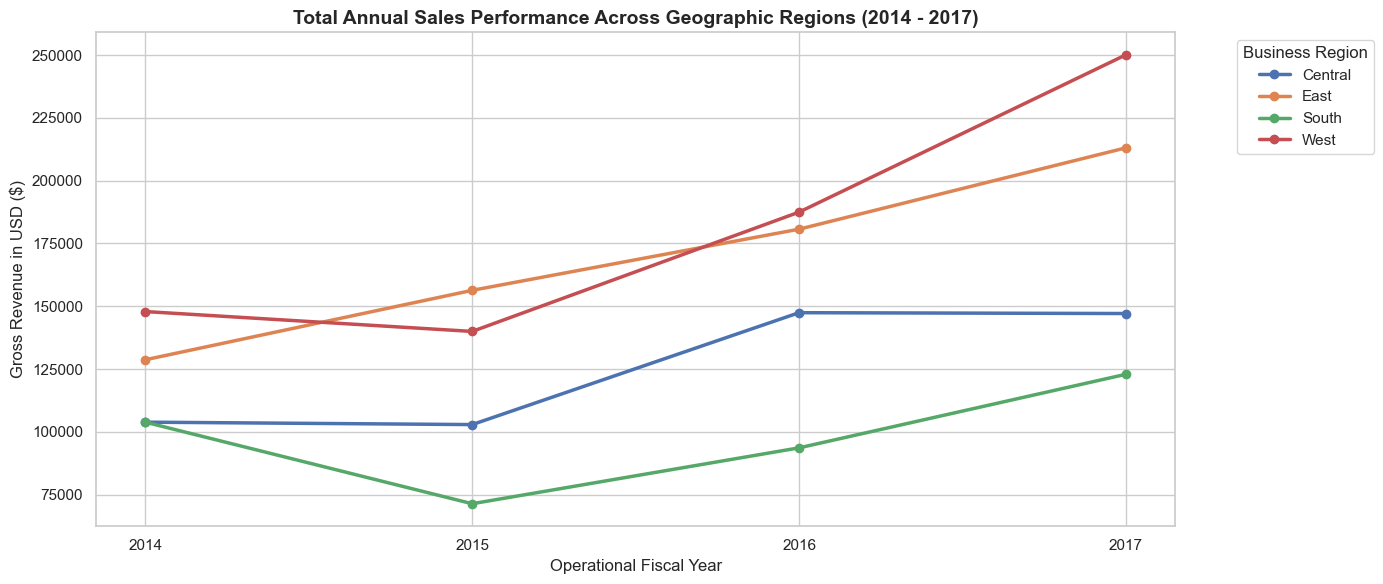

In [4]:
regional_trends = df_raw.groupby(["Year", "Region"])["Sales"].sum().reset_index()
pivot_trends = regional_trends.pivot(index="Year", columns="Region", values="Sales")

pivot_trends.plot(marker="o", linewidth=2.5)
plt.title("Total Annual Sales Performance Across Geographic Regions (2014 - 2017)", fontsize=14, fontweight="bold")
plt.xlabel("Operational Fiscal Year", fontsize=12)
plt.ylabel("Gross Revenue in USD ($)", fontsize=12)
plt.xticks(pivot_trends.index.astype(int))
plt.legend(title="Business Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

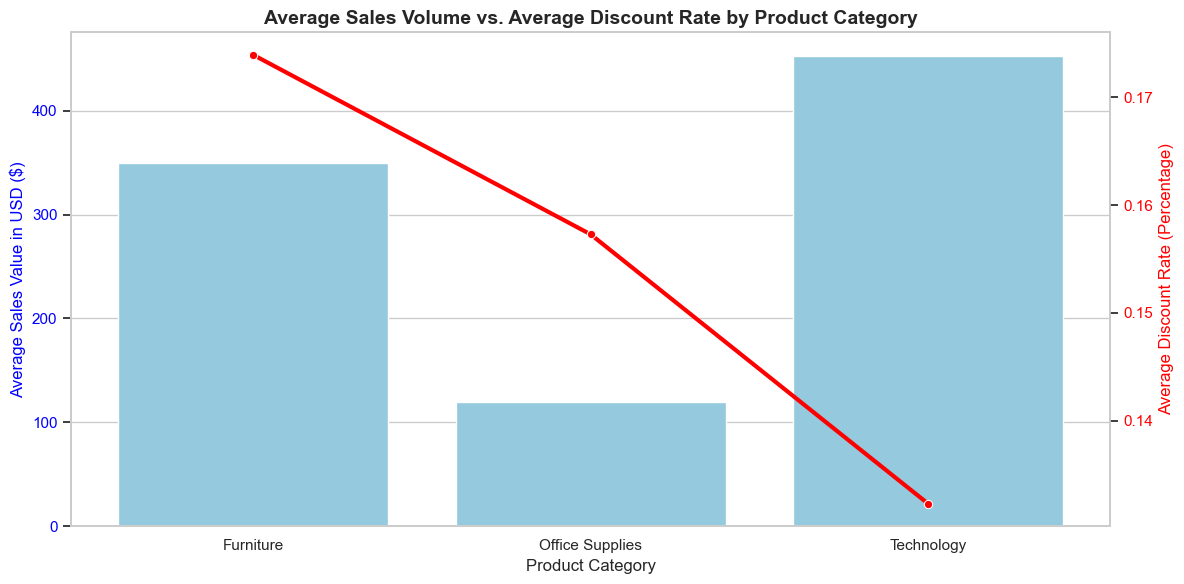

In [5]:
category_perf = df_raw.groupby("Category")[["Sales", "Discount", "Profit"]].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=category_perf, x="Category", y="Sales", ax=ax1, color="skyblue")
ax1.set_title("Average Sales Volume vs. Average Discount Rate by Product Category", fontsize=14, fontweight="bold")
ax1.set_xlabel("Product Category", fontsize=12)
ax1.set_ylabel("Average Sales Value in USD ($)", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
sns.lineplot(data=category_perf, x="Category", y="Discount", ax=ax2, color="red", marker="o", linewidth=3)
ax2.set_ylabel("Average Discount Rate (Percentage)", fontsize=12, color="red")
ax2.tick_params(axis="y", labelcolor="red")
ax2.grid(False)

plt.tight_layout()
plt.show()

C:\Users\KESHAV\AppData\Local\Temp\ipykernel_24644\2737976564.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sub_cat_perf, x="Profit", y="Sub-Category", palette=colors)


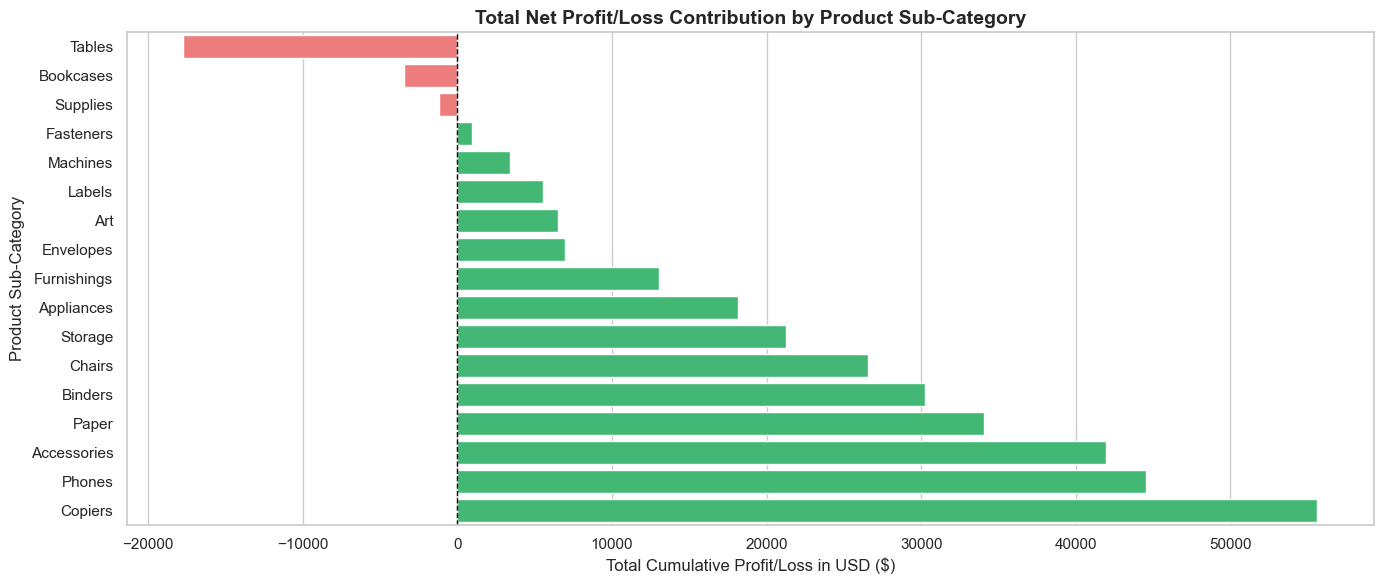

In [6]:
sub_cat_perf = df_raw.groupby("Sub-Category")["Profit"].sum().sort_values().reset_index()

colors = ["tomato" if x < 0 else "le भीgre" for x in sub_cat_perf["Profit"]]
colors = ["#ff6b6b" if x < 0 else "#2ecc71" for x in sub_cat_perf["Profit"]]

sns.barplot(data=sub_cat_perf, x="Profit", y="Sub-Category", palette=colors)
plt.title("Total Net Profit/Loss Contribution by Product Sub-Category", fontsize=14, fontweight="bold")
plt.xlabel("Total Cumulative Profit/Loss in USD ($)", fontsize=12)
plt.ylabel("Product Sub-Category", fontsize=12)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

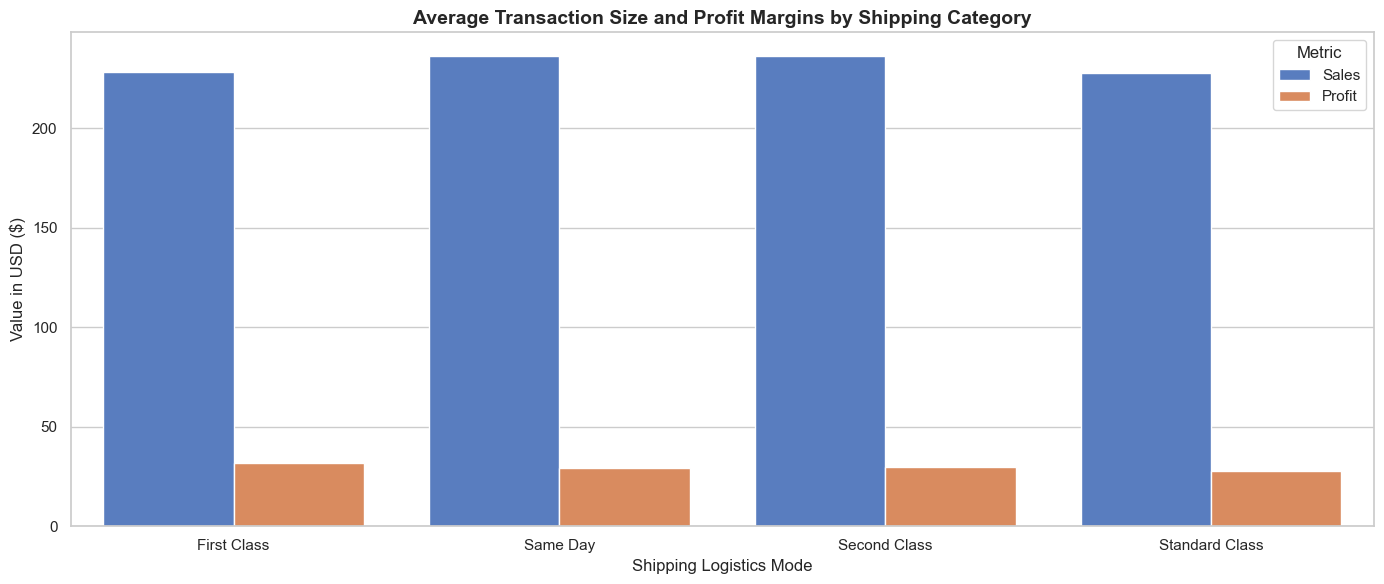

In [7]:
ship_perf = df_raw.groupby("Ship Mode")[["Sales", "Profit"]].mean().reset_index()
melted_ship = pd.melt(ship_perf, id_vars="Ship Mode", value_vars=["Sales", "Profit"], 
                      var_name="Metric", value_name="Amount")

sns.barplot(data=melted_ship, x="Ship Mode", y="Amount", hue="Metric", palette="muted")
plt.title("Average Transaction Size and Profit Margins by Shipping Category", fontsize=14, fontweight="bold")
plt.xlabel("Shipping Logistics Mode", fontsize=12)
plt.ylabel("Value in USD ($)", fontsize=12)
plt.tight_layout()
plt.show()

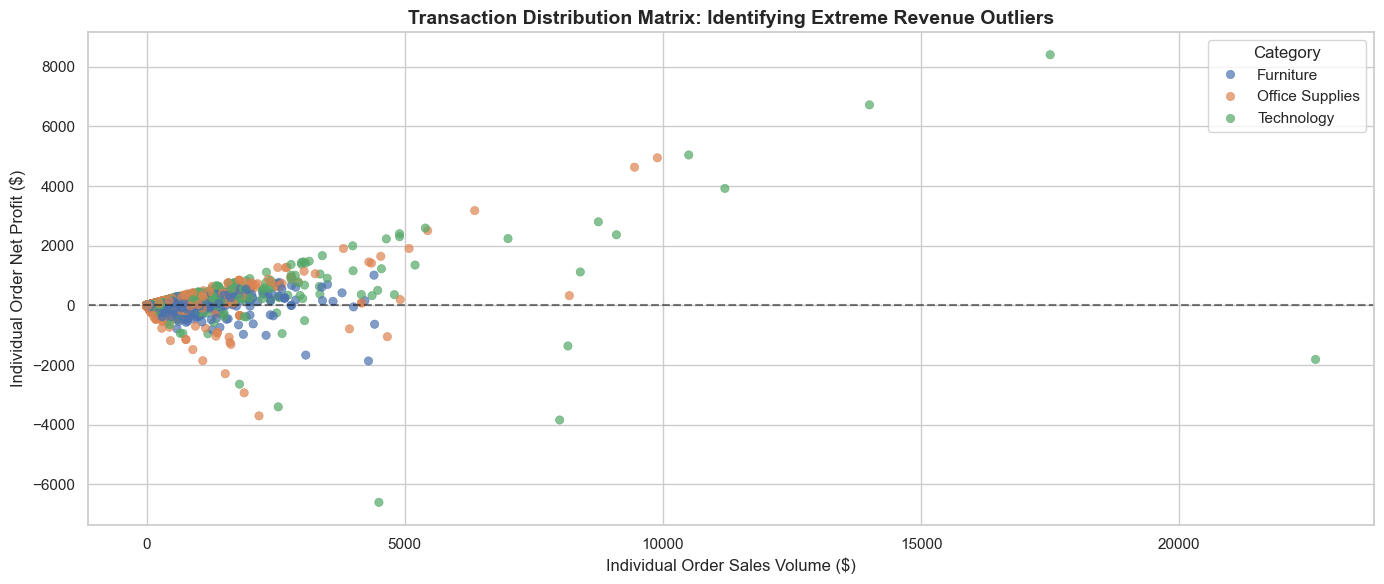

In [8]:
sns.scatterplot(data=df_raw, x="Sales", y="Profit", hue="Category", alpha=0.7, edgecolor=None)
plt.title("Transaction Distribution Matrix: Identifying Extreme Revenue Outliers", fontsize=14, fontweight="bold")
plt.xlabel("Individual Order Sales Volume ($)", fontsize=12)
plt.ylabel("Individual Order Net Profit ($)", fontsize=12)
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# 1. Aggregate daily transactions into clean weekly intervals by Region and Category
df_weekly = df_raw.groupby(["Year", "Month", "Region", "Category"])["Sales"].sum().reset_index()

# 2. Create standard structural inputs (X) and target outputs (y)
X_raw = df_weekly[["Year", "Month", "Region", "Category"]].copy()
y_raw = df_weekly["Sales"]

# 3. Apply a Log Transformation to compress extreme bulk order outliers
y_log = np.log1p(y_raw)

# 4. Convert categorical text columns into standard numerical binary columns (One-Hot Encoding)
X_encoded = pd.get_dummies(X_raw, columns=["Region", "Category"], drop_first=True)

# 5. Split data sequentially into Training (80%) and Testing (20%) sets
X_train, X_test, y_train_log, y_test_log = train_test_split(X_encoded, y_log, test_size=0.2, shuffle=False)

# Keep a raw copy of test labels for true-dollar baseline comparison
y_test_raw = y_raw.iloc[y_test_log.index].values

print("Training Feature Matrix Shape:", X_train.shape)
print("Testing Target Vector Shape:", y_test_log.shape)

Training Feature Matrix Shape: (458, 7)
Testing Target Vector Shape: (115,)


In [10]:
# 1. Initialize and fit the classic Linear Regression baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_log)

# 2. Initialize and fit the sequential XGBoost regressor
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train_log)

# 3. Generate log-scale predictions
lr_preds_log = lr_model.predict(X_test)
xgb_preds_log = xgb_model.predict(X_test)

# 4. Inverse-transform log outputs back into actual, understandable dollar amounts
lr_preds_dollars = np.expm1(lr_preds_log)
xgb_preds_dollars = np.expm1(xgb_preds_log)

# 5. Calculate global performance matrices using scikit-learn metrics
print("--- LINEAR REGRESSION PERFORMANCE ---")
print("Mean Absolute Error (MAE): $", round(mean_absolute_error(y_test_raw, lr_preds_dollars), 2))
print("Root Mean Squared Error (RMSE): $", round(root_mean_squared_error(y_test_raw, lr_preds_dollars), 2))

print("\n--- XGBOOST REGRESSOR PERFORMANCE ---")
print("Mean Absolute Error (MAE): $", round(mean_absolute_error(y_test_raw, xgb_preds_dollars), 2))
print("Root Mean Squared Error (RMSE): $", round(root_mean_squared_error(y_test_raw, xgb_preds_dollars), 2))

--- LINEAR REGRESSION PERFORMANCE ---
Mean Absolute Error (MAE): $ 2499.51
Root Mean Squared Error (RMSE): $ 3802.69

--- XGBOOST REGRESSOR PERFORMANCE ---
Mean Absolute Error (MAE): $ 3019.23
Root Mean Squared Error (RMSE): $ 4453.19


In [11]:
# Combine your test parameters, true sales numbers, and model predictions into a single export table
df_dashboard = X_raw.iloc[y_test_log.index].copy()
df_dashboard["Actual_Sales"] = y_test_raw
df_dashboard["Linear_Regression_Forecast"] = lr_preds_dollars
df_dashboard["XGBoost_Forecast"] = xgb_preds_dollars

# Save the matrix to your project data folder
df_dashboard.to_csv("../data/dashboard_feed.csv", index=False)
print("Data export complete! The file 'data/dashboard_feed.csv' is ready for Power BI ingestion.")

Data export complete! The file 'data/dashboard_feed.csv' is ready for Power BI ingestion.
